# Estimation of the intensity of a point process

In [114]:
import sys
sys.path.append("../..")
from src.point_process import *
import matplotlib.pyplot as plt
import time
from src.utils import format_time, color
import json

**Intensity estimators**

Two estimators are considered for the intensity $\lambda$:

- The first one is the standard estimator:
$$
\hat{\lambda} = \frac{N(W)}{\nu(W)},
$$
where $N(W)$ is the number of points in the window $W$ and $\nu(W)$ its area.

- The second one is an estimator that we will denote $\hat{\lambda}_S$ and that is computed via the formula:
$$
\hat{\lambda}_S(r) = \sum_{x \in N} p_S(x, r),
$$

where 
$$ 
p_S(x, r) = \frac{\nu_{d-1} \left( W \cap \partial b(x, r) \right)}{d b_d r^{d-1} \overline{\gamma}_W(r)}
$$

For a 2d rectangular case, this formula becomes:

$$ 
p_S(x, r) = \frac{\nu_{1} \left( W \cap \partial b(x, r) \right)}{2 \pi r \overline{\gamma}_W(r)}, 
$$

where

$$
\overline{\gamma}_W(r) =
\begin{cases}
    wh - \frac{2r}{\pi} (w + h) + \frac{r^2}{\pi}, & \text{for } r \leq w, \\[10pt]
    \frac{wh}{\pi} \left( 2 \arcsin \left( \frac{w}{r} \right) - \frac{w}{h} - 2 \left( \frac{r}{w} - \sqrt{\frac{r^2}{w^2} - 1} \right) \right), & \text{for } w < r \leq h.
\end{cases}
$$

The computation of $\nu_{1} \left( W \cap \partial b(x, r) \right)$ is done by the function `rect` in `src\point_process.py`. The result `ra` is a vector of two elements where `ra[0]` is $\nu \left( W \cap b(x, r) \right)$ and `ra[1]` is $\nu_{1} \left( W \cap \partial b(x, r) \right)$.

**Example 1: _Poisson_ process**

1- Standard estimator

In [115]:
with open('../../parameters/poisson-process-m-01.json', 'r') as file:
    params = json.load(file)

In [116]:
W = params['W']
w, h = W
lam = params['lam']

In [117]:
poisson_process = PoissonProcess(lam)
points_poisson = poisson_process.generate(W, seed=42)

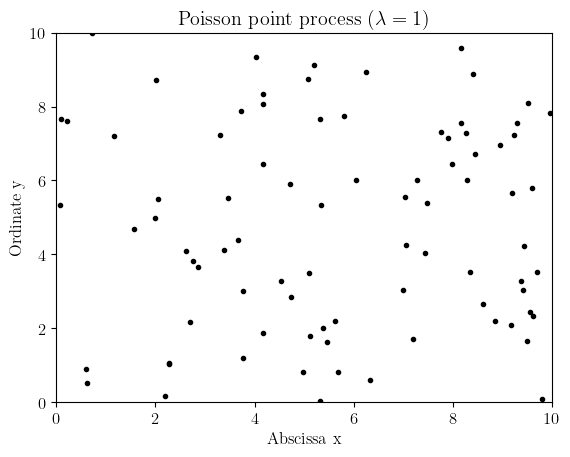

In [118]:
display(points_poisson, window=(10, 10), title=fr"Poisson point process ($\lambda = {lam}$)")

In [119]:
def intensities(points: np.ndarray, W:tuple[float, float], start: float, n_steps: int = 100, verbose: bool = False):
    
    w, h = W
    a_range = np.linspace(start, w, n_steps)
    b_range = np.linspace(start, h, n_steps)

    intensities = np.zeros((n_steps))

    if verbose: t_init = time.time()
    for i, (a, b) in enumerate(zip(a_range, b_range)):
        trimmed_points = trim_process(points, bottom_left=(0, 0), W=(a, b))
        intensities[i] = intensity(trimmed_points, W=(a, b))
        if verbose: print(f'--> Step {i+1:03}/{n_steps}'.rjust(18, " ") + f' -- Elapsed time: {format_time(time.time() - t_init)}')
        
    area_range = a_range*b_range
    return area_range, intensities

In [120]:
n_steps = 100
area_range, intensities_poisson = intensities(points_poisson, W, 10, n_steps)

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_770216/911368574.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(area_range, n_steps*[lam], label='$\lambda$', color=color['orange'])
/tmp/ipykernel_770216/911368574.py:8: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(area_range, intensities_poisson, label='$\hat{\lambda}$', color=color['darkblue'])
/tmp/ipykernel_770216/911368574.py:12: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Intensity estimate $\hat{\lambda}$')
/tmp/ipykernel_770216/911368574.py:13: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Poisson($\lambda$={lam: .2f

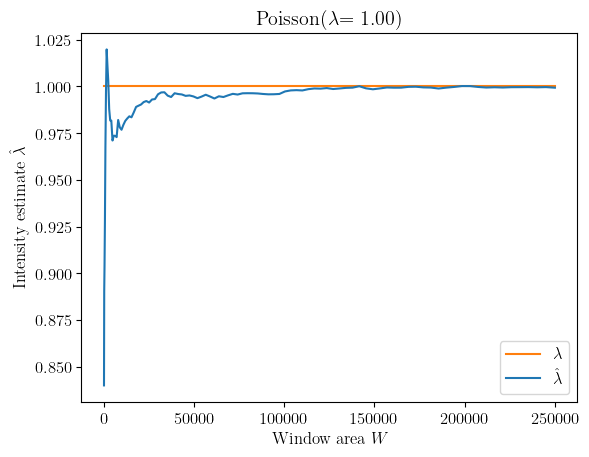

In [121]:
plt.rcParams.update({
    "text.usetex": True,          # Use LaTeX to render text
    "font.family": "serif",       # Match LaTeX serif font
    "font.size": 12
    })

plt.plot(area_range, n_steps*[lam], label='$\lambda$', color=color['orange'])
plt.plot(area_range, intensities_poisson, label='$\hat{\lambda}$', color=color['darkblue'])
plt.legend()

plt.xlabel('Window area $W$')
plt.ylabel('Intensity estimate $\hat{\lambda}$')
plt.title(f'Poisson($\lambda$={lam: .2f})')

plt.savefig('../../img/intensity-estim-1.eps', format='eps')
plt.show()

2- S estimator

In [122]:
def intensities_s(points: np.ndarray, W: tuple[float, float], start: float, r_range: np.ndarray, n_steps: int = 100, verbose: bool = False):
    
    w, h = W; r_steps = len(r_range)
    a_range = np.linspace(start, w, n_steps)
    b_range = np.linspace(start, h, n_steps)
    
    intensities_s = np.zeros((n_steps, r_steps))

    if verbose: t_init = time.time()
    for i, (a, b) in enumerate(zip(a_range, b_range)):
        trimmed_points = trim_process(points, bottom_left=(0, 0), W=(a, b))
        for j, r in enumerate(r_range):
            intensities_s[i, j] = intensity(trimmed_points, W=(a, b), estimator='standard', r=r)
            if verbose: print(f'--> Step {r_steps*i + j + 1}/{n_steps*r_steps}'.rjust(18, " ") + f' -- Elapsed time: {format_time(time.time() - t_init)}')
        
    area_range = a_range*b_range
    return area_range, intensities_s

In [123]:
r_range = np.linspace(0.1*w, 0.2*w, 100)
area_range_s, intensities_poisson_s = intensities_s(points_poisson, W, 10, r_range)

<>:9: SyntaxWarning: invalid escape sequence '\V'
<>:14: SyntaxWarning: invalid escape sequence '\V'
<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\V'
<>:14: SyntaxWarning: invalid escape sequence '\V'
<>:15: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_770216/3778554731.py:9: SyntaxWarning: invalid escape sequence '\V'
  plt.plot(area_range_s, rmse, label='$\Vert\lambda - \hat{\lambda}_S\Vert_{\infty}$')
/tmp/ipykernel_770216/3778554731.py:14: SyntaxWarning: invalid escape sequence '\V'
  plt.ylabel('Infinite norm $\Vert \lambda - \hat{\lambda}_S \Vert_{\infty}$')
/tmp/ipykernel_770216/3778554731.py:15: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Poisson($\lambda$={lam: .2f})')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


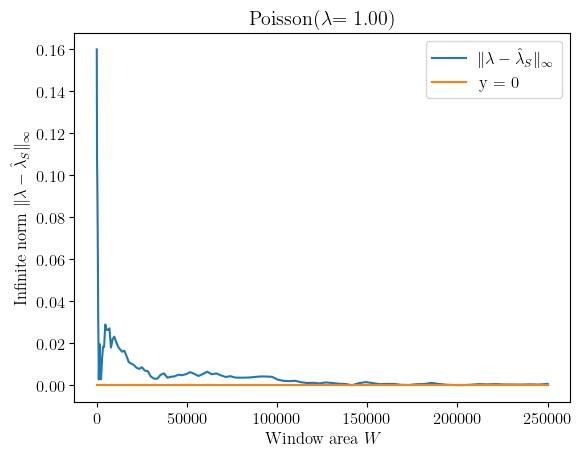

In [124]:
rmse = np.linalg.norm(intensities_poisson_s - np.full_like(r_range, lam), ord=np.inf, axis=1)

plt.rcParams.update({
    "text.usetex": True,          # Use LaTeX to render text
    "font.family": "serif",       # Match LaTeX serif font
    "font.size": 12
    })

plt.plot(area_range_s, rmse, label='$\Vert\lambda - \hat{\lambda}_S\Vert_{\infty}$')
plt.plot(area_range_s, np.zeros_like(area_range_s), label='y = 0')
plt.legend()

plt.xlabel('Window area $W$')
plt.ylabel('Infinite norm $\Vert \lambda - \hat{\lambda}_S \Vert_{\infty}$')
plt.title(f'Poisson($\lambda$={lam: .2f})')

plt.savefig('../../img/intensity-estim-2.eps', format='eps')
plt.show()